In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Data, Models, and Utilities
from sklearn.tree import DecisionTreeClassifier # Changed from DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

from sklearn.tree import plot_tree

# Set a style for plots
sns.set_style("whitegrid")

In [26]:
def calculate_weighted_leaf_gini_impurity(model):
    """
    Calculates the weighted average Gini impurity of the leaf nodes of a DecisionTreeClassifier.
    """
    tree = model.tree_
    n_nodes = tree.node_count
    children_left = tree.children_left
    children_right = tree.children_right
    impurity = tree.impurity
    n_node_samples = tree.n_node_samples

    leaf_gini_sum = 0
    total_leaf_samples = 0

    # Stack for DFS traversal
    stack = [0] # Start with root node (node_id 0)

    while stack:
        node_id = stack.pop()

        # If it's a leaf node
        if children_left[node_id] == children_right[node_id]:
            leaf_gini_sum += impurity[node_id] * n_node_samples[node_id]
            total_leaf_samples += n_node_samples[node_id]
        else: # Not a leaf, add children to stack
            stack.append(children_left[node_id])
            stack.append(children_right[node_id])

    if total_leaf_samples == 0: # Should not happen for a trained tree with samples
        return 0.0

    return leaf_gini_sum / total_leaf_samples

In [2]:
encoded_crash_df = pd.read_csv(
    "https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoded_crash_data.csv",
    dtype={'medication_use': str}  # To avoid slowing processing speed, specify data type
)

In [6]:
# Identify the columns to consider for dropping NaNs
relevant_cols = ['Speed_Limit', 'Injury_Severity_Encoded', 'Vehicle_Damage_Encoded',
       'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
       'substance_encoded', 'distract_encoded']

# Drop rows where any of the relevant columns have NaN values from crash_analysis_df
# Use .copy() to ensure use of separate DataFrame, avoid SettingWithCopyWarning
cleaned_crash_df = encoded_crash_df.dropna(subset=relevant_cols).copy()

# Define features (X) and target (y) from the cleaned_crash_df
X = cleaned_crash_df[['Speed_Limit', 'Vehicle_Damage_Encoded',
                      'Surface_Condition_Encoded', 'Ambient_Light_Encoded',
                      'Weather_Encoded', 'substance_encoded', 'distract_encoded']].copy()
y = cleaned_crash_df["Injury_Severity_Encoded"].copy()

----------
##For a full key to the encoding, see bottom of document or the notebook crash_df_encoding.ipynb
------------

-----------
####Train/Test split
Set up design matrix and response vector.   
Create a train/test split.  
No need to scale or standardize data for these methods.

In [7]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset features: {list(X.columns)}")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset features: ['Speed_Limit', 'Vehicle_Damage_Encoded', 'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded', 'substance_encoded', 'distract_encoded']

Training set size: 23526 samples
Testing set size: 5882 samples


------------
####Decision Tree Regressor
Initialize and train the regressor,  
then make predictions.

##Note:  Regressor cannot be used for discrete data.  Decision Tree Classifier must be used.

####Model Metrics for Decision Tree of max depth 8:  
calculate the Mean Squared Error (MSE), R^2, and the accuracy score.

In [8]:
# Initialize and train the Decision Tree Classifier

# Set max_depth to control complexity and prevent extreme overfitting
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42) # Changed to Classifier
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

In [9]:
# Calculate metrics
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("--- Decision Tree Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")
print(f"Accuracy Score: {dt_accuracy:.3f}")

# Store results for comparison
dt_results = {'MSE': dt_mse, 'R2': dt_r2, 'Accuracy': dt_accuracy,  'Model': 'Decision Tree'}

--- Decision Tree Regressor Metrics ---
Mean Squared Error (MSE): 0.457
R-squared (R2) Score: -0.193
Accuracy Score: 0.824


----------------
####Visualizing the Decision Tree Depth 8
using sklearn.tree.plot_tree

--- Decision Tree Structure Visualization ---


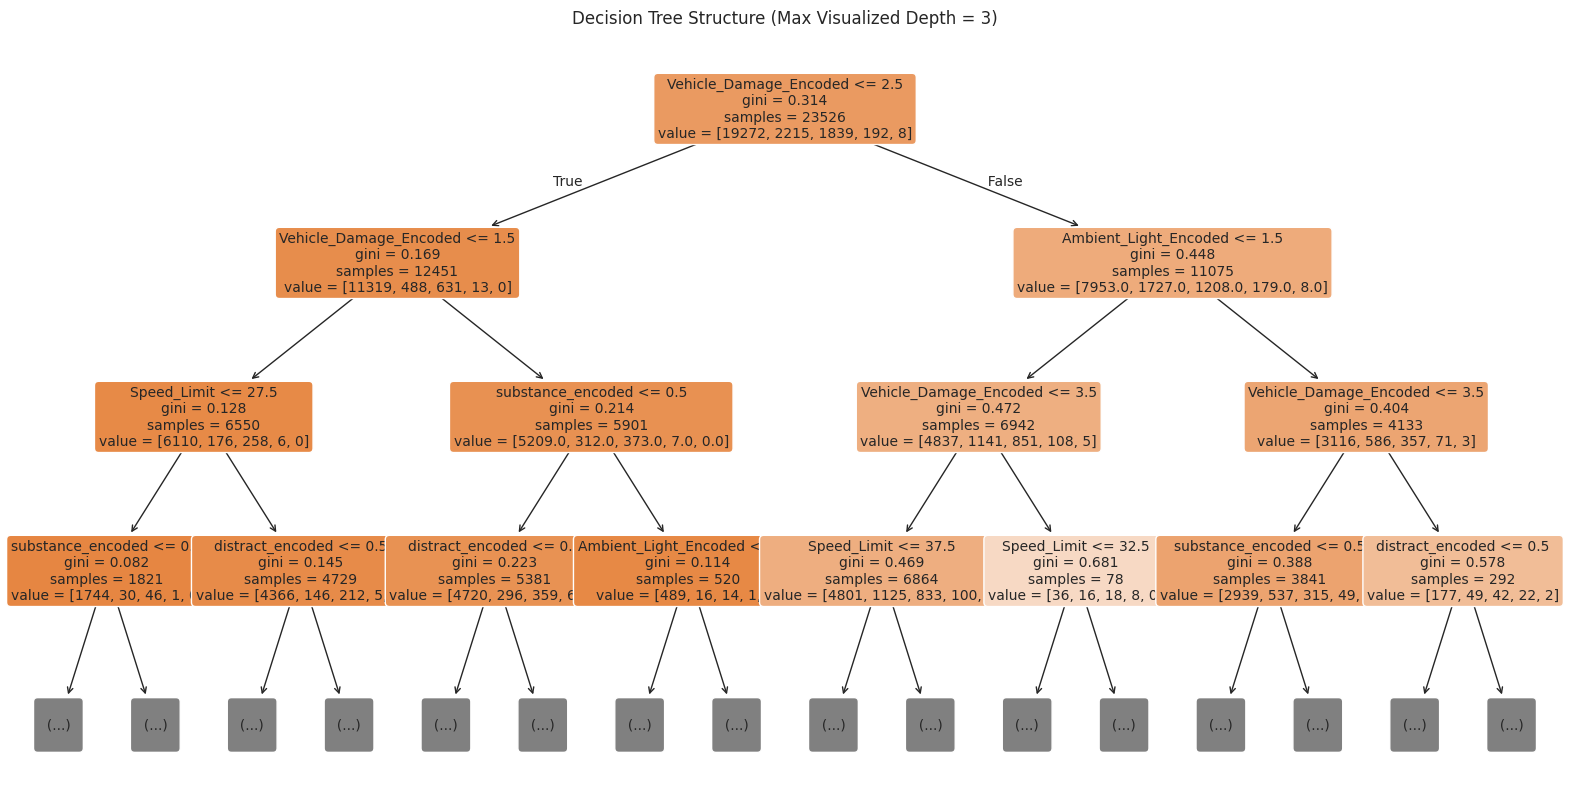

In [10]:
print("--- Decision Tree Structure Visualization ---")

# Set the maximum depth to visualize for readability
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,  # Limit depth for a clearer image
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3)")
plt.show()

#### Decision Tree Classifier (max_depth=7)

Initialize, train, and make predictions with the Decision Tree Classifier using a `max_depth` of 7.

In [11]:
# Initialize and train the Decision Tree Classifier with max_depth=7
dt_model_depth7 = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model_depth7.fit(X_train, y_train)

# Make predictions
dt_predictions_depth7 = dt_model_depth7.predict(X_test)

#### Model Metrics for Decision Tree of max depth 7:

Calculate the Mean Squared Error (MSE), R^2, and the accuracy score for the model with `max_depth=7`.

In [12]:
# Calculate metrics for dt_model_depth7
dt_mse_depth7 = mean_squared_error(y_test, dt_predictions_depth7)
dt_r2_depth7 = r2_score(y_test, dt_predictions_depth7)
dt_accuracy_depth7 = accuracy_score(y_test, dt_predictions_depth7)

print("--- Decision Tree Regressor Metrics (max_depth=7) ---")
print(f"Mean Squared Error (MSE): {dt_mse_depth7:.3f}")
print(f"R-squared (R2) Score: {dt_r2_depth7:.3f}")
print(f"Accuracy Score: {dt_accuracy_depth7:.3f}")

# Store results for comparison
dt_results_depth7 = {'MSE': dt_mse_depth7, 'R2': dt_r2_depth7, 'Accuracy': dt_accuracy_depth7, 'Model': 'Decision Tree (Depth 7)'}

--- Decision Tree Regressor Metrics (max_depth=7) ---
Mean Squared Error (MSE): 0.456
R-squared (R2) Score: -0.191
Accuracy Score: 0.825


#### Visualizing the Decision Tree (max_depth=7)

Visualizing the structure of the Decision Tree trained with `max_depth=7`.

--- Decision Tree Structure Visualization (max_depth=7) ---


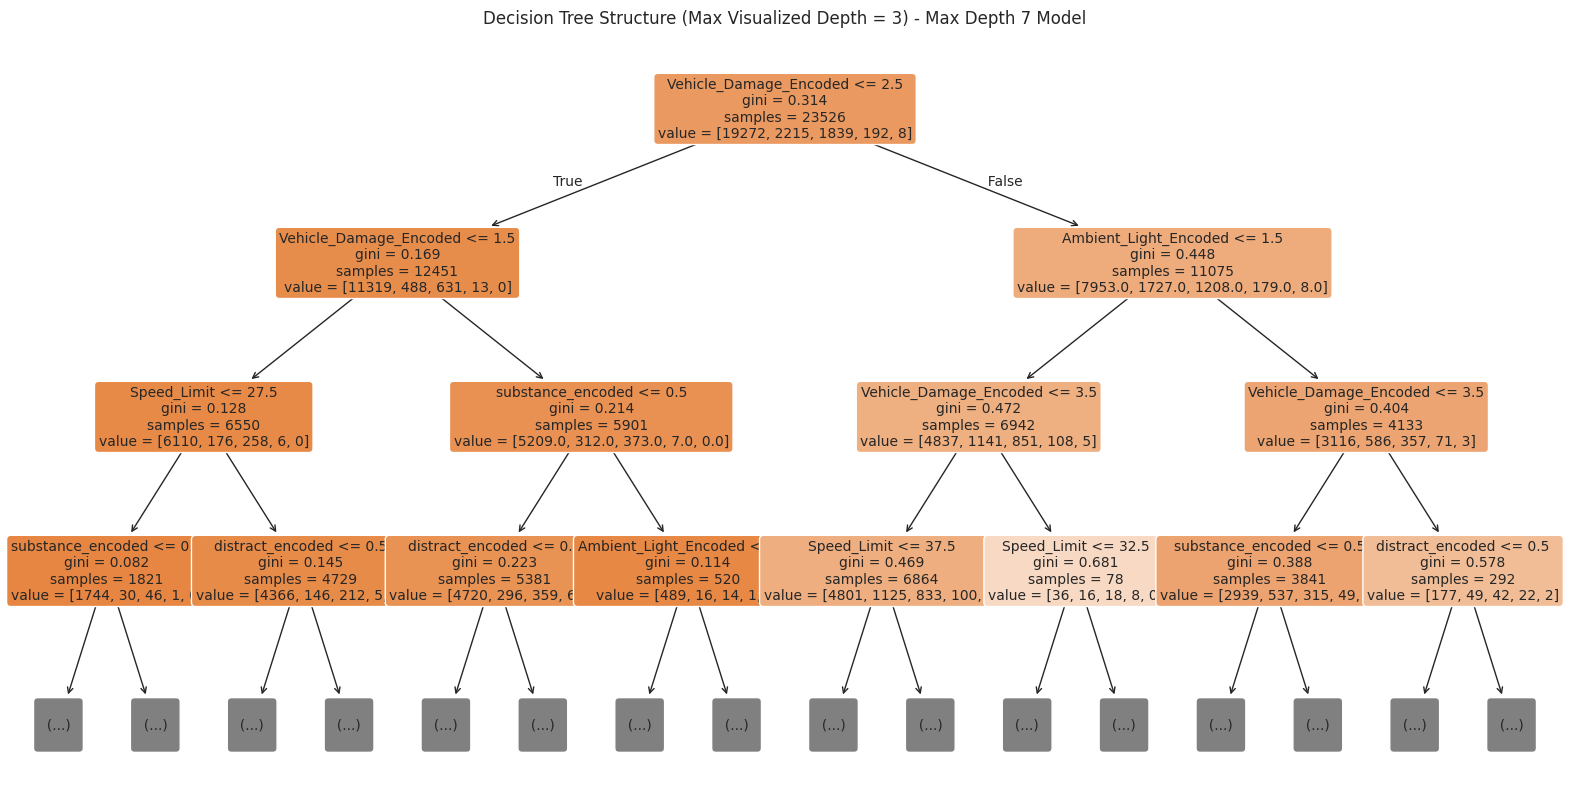

In [13]:
print("--- Decision Tree Structure Visualization (max_depth=7) ---")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model_depth7,
    max_depth=3,  # Limit depth for a clearer image, visualize top 3 levels
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3) - Max Depth 7 Model")
plt.show()

#### Decision Tree Classifier (max_depth=5)

Initialize, train, and make predictions with the Decision Tree Classifier using a `max_depth` of 5.

In [14]:
# Initialize and train the Decision Tree Classifier with max_depth=5
dt_model_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model_depth5.fit(X_train, y_train)

# Make predictions
dt_predictions_depth5 = dt_model_depth5.predict(X_test)

#### Model Metrics for Decision Tree of max depth 5:

Calculate the Mean Squared Error (MSE), R^2, and the accuracy score for the model with `max_depth=5`.

In [15]:
# Calculate metrics for dt_model_depth5
dt_mse_depth5 = mean_squared_error(y_test, dt_predictions_depth5)
dt_r2_depth5 = r2_score(y_test, dt_predictions_depth5)
dt_accuracy_depth5 = accuracy_score(y_test, dt_predictions_depth5)

print("--- Decision Tree Regressor Metrics (max_depth=5) ---")
print(f"Mean Squared Error (MSE): {dt_mse_depth5:.3f}")
print(f"R-squared (R2) Score: {dt_r2_depth5:.3f}")
print(f"Accuracy Score: {dt_accuracy_depth5:.3f}")

# Store results for comparison
dt_results_depth5 = {'MSE': dt_mse_depth5, 'R2': dt_r2_depth5, 'Accuracy': dt_accuracy_depth5, 'Model': 'Decision Tree (Depth 5)'}

--- Decision Tree Regressor Metrics (max_depth=5) ---
Mean Squared Error (MSE): 0.451
R-squared (R2) Score: -0.179
Accuracy Score: 0.825


###Visualizing the Decision Tree (max_depth=5)

--- Decision Tree Structure Visualization (max_depth=5) ---


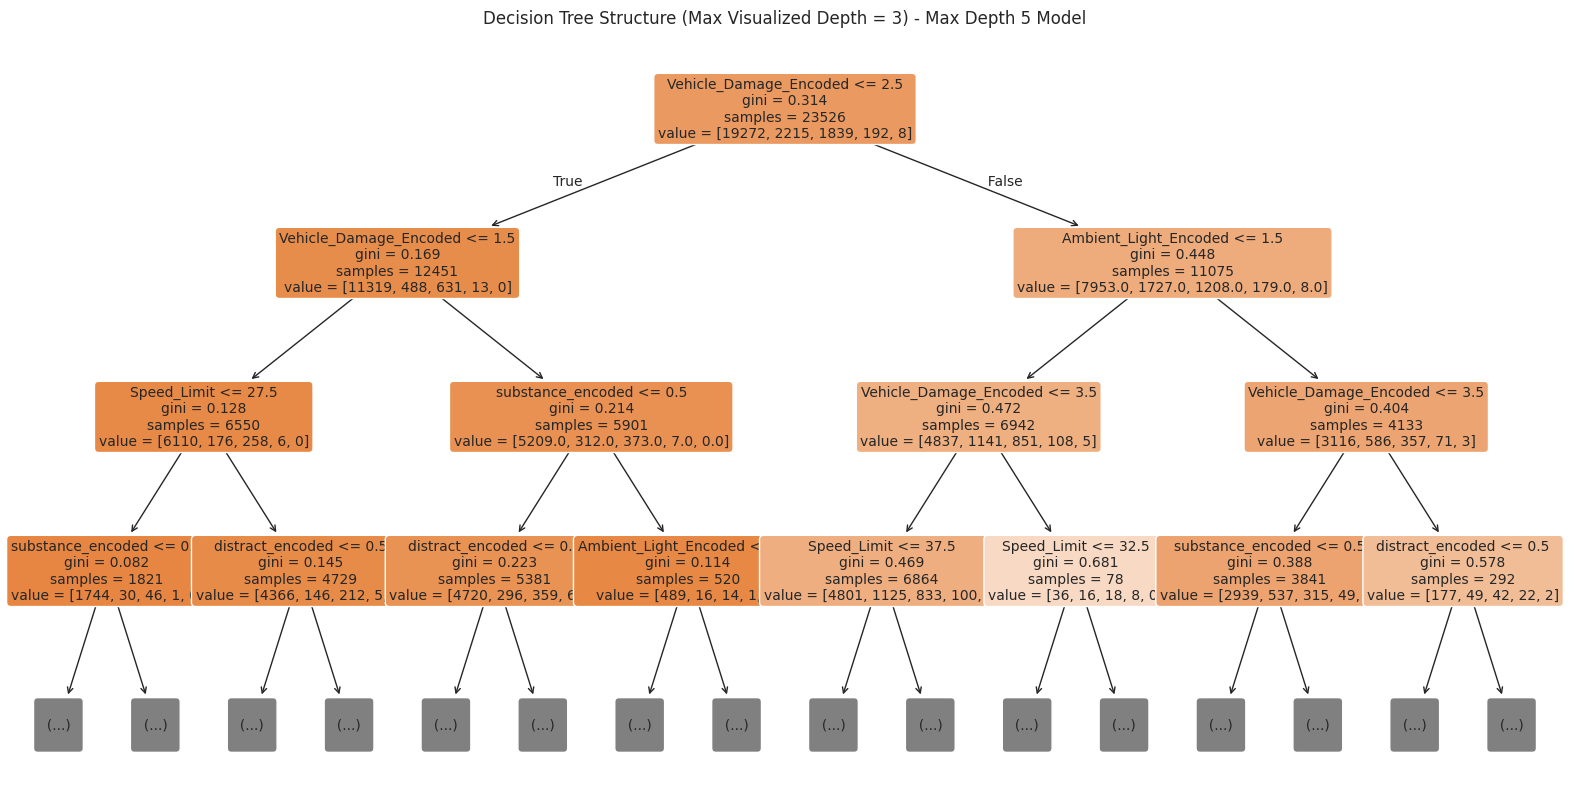

In [16]:
print("--- Decision Tree Structure Visualization (max_depth=5) ---")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model_depth5,
    max_depth=3,  # Limit depth for a clearer image, visualize top 3 levels
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3) - Max Depth 5 Model")
plt.show()

----------------
### Decision Tree Classifier (max_depth=3)

Initialize, train, and make predictions with the Decision Tree Classifier using a `max_depth` of 3.

In [20]:
# Initialize and train the Decision Tree Classifier with max_depth=3
dt_model_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model_depth3.fit(X_train, y_train)

# Make predictions
dt_predictions_depth3 = dt_model_depth3.predict(X_test)

#### Model Metrics for Decision Tree of max depth 3:

Calculate the Mean Squared Error (MSE), R^2, and the accuracy score for the model with `max_depth=3`.

In [21]:
# Calculate metrics for dt_model_depth3
dt_mse_depth3 = mean_squared_error(y_test, dt_predictions_depth3)
dt_r2_depth3 = r2_score(y_test, dt_predictions_depth3)
dt_accuracy_depth3 = accuracy_score(y_test, dt_predictions_depth3)

print("--- Decision Tree Regressor Metrics (max_depth=3) ---")
print(f"Mean Squared Error (MSE): {dt_mse_depth3:.3f}")
print(f"R-squared (R2) Score: {dt_r2_depth3:.3f}")
print(f"Accuracy Score: {dt_accuracy_depth3:.3f}")

# Store results for comparison
dt_results_depth3 = {'MSE': dt_mse_depth3, 'R2': dt_r2_depth3, 'Accuracy': dt_accuracy_depth3, 'Model': 'Decision Tree (Depth 3)'}

--- Decision Tree Regressor Metrics (max_depth=3) ---
Mean Squared Error (MSE): 0.452
R-squared (R2) Score: -0.180
Accuracy Score: 0.825


#### Visualizing the Decision Tree (max_depth=3)

Visualizing the structure of the Decision Tree trained with `max_depth=3`.

--- Decision Tree Structure Visualization (max_depth=3) ---


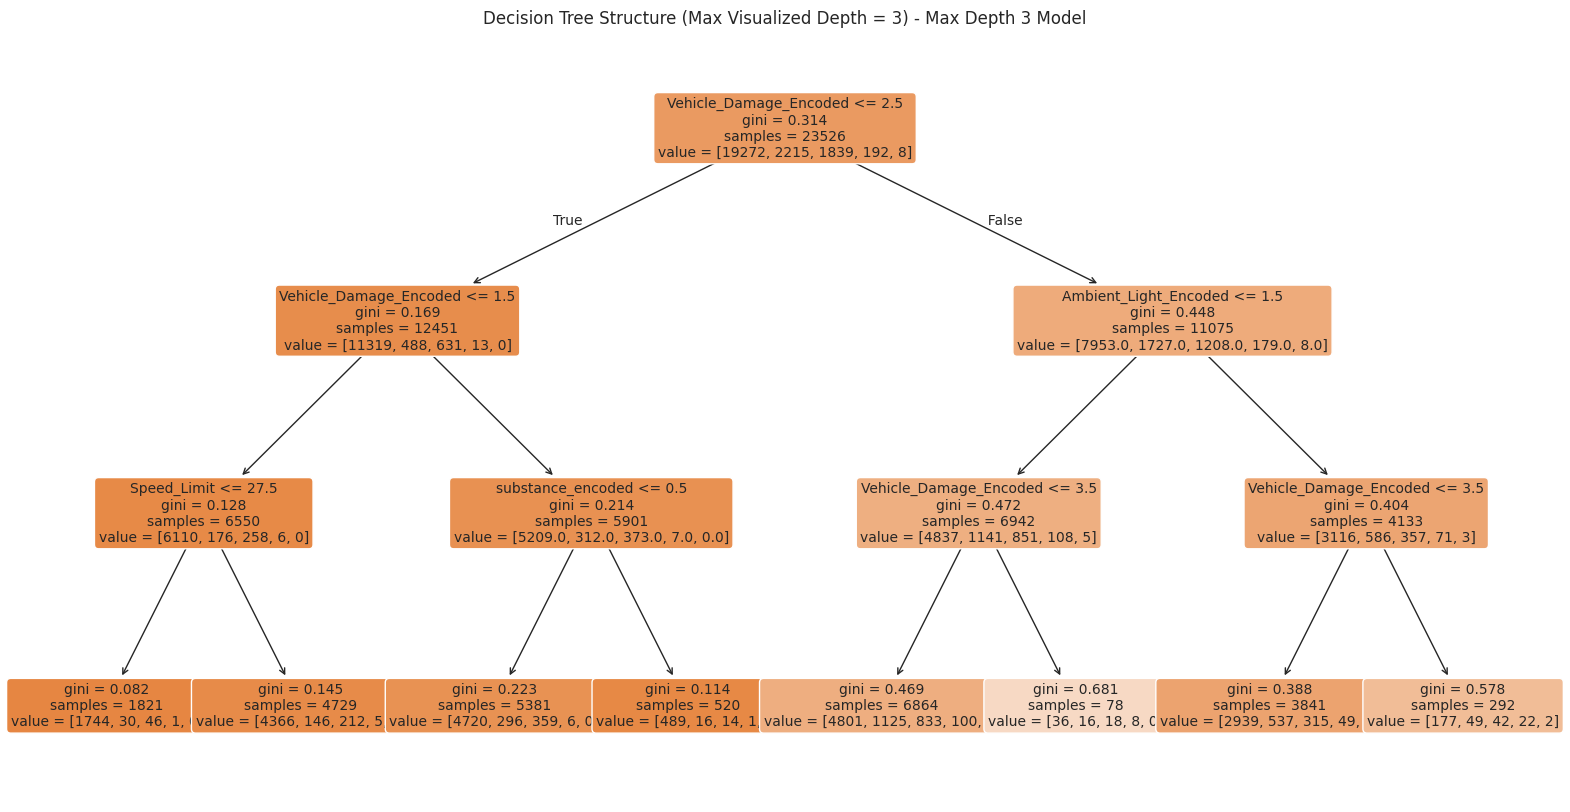

In [22]:
print("--- Decision Tree Structure Visualization (max_depth=3) ---")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model_depth3,
    max_depth=3,  # Limit depth for a clearer image, visualize top 3 levels
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3) - Max Depth 3 Model")
plt.show()

#### Decision Tree Classifier (max_depth=2)

Initialize, train, and make predictions with the Decision Tree Classifier using a `max_depth` of 2.

In [23]:
# Initialize and train the Decision Tree Classifier with max_depth=2
dt_model_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model_depth2.fit(X_train, y_train)

# Make predictions
dt_predictions_depth2 = dt_model_depth2.predict(X_test)

#### Model Metrics for Decision Tree of max depth 2:

Calculate the Mean Squared Error (MSE), R^2, and the accuracy score for the model with `max_depth=2`.

In [24]:
# Calculate metrics for dt_model_depth2
dt_mse_depth2 = mean_squared_error(y_test, dt_predictions_depth2)
dt_r2_depth2 = r2_score(y_test, dt_predictions_depth2)
dt_accuracy_depth2 = accuracy_score(y_test, dt_predictions_depth2)

print("--- Decision Tree Regressor Metrics (max_depth=2) ---")
print(f"Mean Squared Error (MSE): {dt_mse_depth2:.3f}")
print(f"R-squared (R2) Score: {dt_r2_depth2:.3f}")
print(f"Accuracy Score: {dt_accuracy_depth2:.3f}")

# Store results for comparison
dt_results_depth2 = {'MSE': dt_mse_depth2, 'R2': dt_r2_depth2, 'Accuracy': dt_accuracy_depth2, 'Model': 'Decision Tree (Depth 2)'}

--- Decision Tree Regressor Metrics (max_depth=2) ---
Mean Squared Error (MSE): 0.452
R-squared (R2) Score: -0.180
Accuracy Score: 0.825


#### Calculate Weighted Leaf Gini Impurity for Each Model

Calculating the weighted average Gini impurity of the leaf nodes for each Decision Tree model to include in the comparison table.

In [27]:
gini_depth8 = calculate_weighted_leaf_gini_impurity(dt_model)
gini_depth7 = calculate_weighted_leaf_gini_impurity(dt_model_depth7)
gini_depth5 = calculate_weighted_leaf_gini_impurity(dt_model_depth5)
gini_depth3 = calculate_weighted_leaf_gini_impurity(dt_model_depth3)
gini_depth2 = calculate_weighted_leaf_gini_impurity(dt_model_depth2)

print(f"Weighted Leaf Gini Impurity (Depth 8): {gini_depth8:.3f}")
print(f"Weighted Leaf Gini Impurity (Depth 7): {gini_depth7:.3f}")
print(f"Weighted Leaf Gini Impurity (Depth 5): {gini_depth5:.3f}")
print(f"Weighted Leaf Gini Impurity (Depth 3): {gini_depth3:.3f}")
print(f"Weighted Leaf Gini Impurity (Depth 2): {gini_depth2:.3f}")

Weighted Leaf Gini Impurity (Depth 8): 0.292
Weighted Leaf Gini Impurity (Depth 7): 0.294
Weighted Leaf Gini Impurity (Depth 5): 0.299
Weighted Leaf Gini Impurity (Depth 3): 0.299
Weighted Leaf Gini Impurity (Depth 2): 0.299


#### Visualizing the Decision Tree (max_depth=2)

Visualizing the structure of the Decision Tree trained with `max_depth=2`.

--- Decision Tree Structure Visualization (max_depth=2) ---


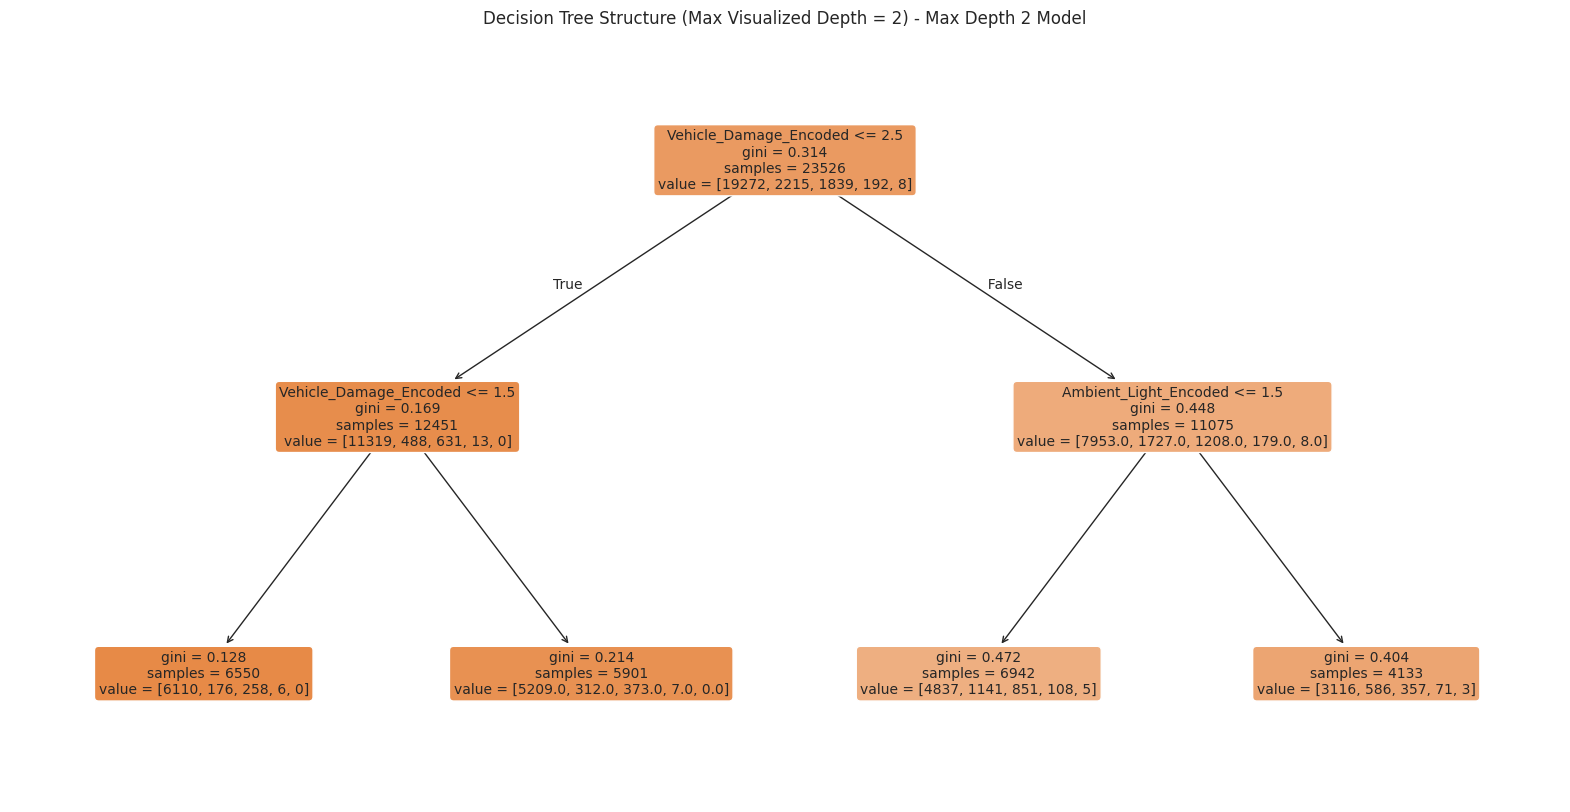

In [25]:
print("--- Decision Tree Structure Visualization (max_depth=2) ---")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model_depth2,
    max_depth=2,  # Visualizing the full depth of this model
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 2) - Max Depth 2 Model")
plt.show()


-------------------
#### Visualization of Actual vs. Predicted Injury Severity (max_depth=2)

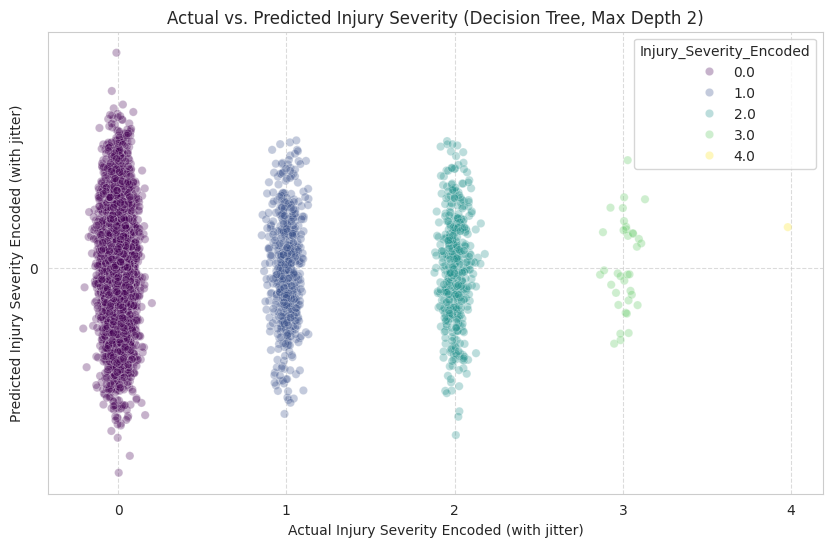

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_test + np.random.normal(0, 0.05, len(y_test)),  # Add jitter for better visibility of discrete points
    y=dt_predictions_depth2 + np.random.normal(0, 0.05, len(dt_predictions_depth2)),
    alpha=0.3, # Adjust transparency for density
    hue=y_test, # Color by actual class
    palette='viridis'
)
plt.title('Actual vs. Predicted Injury Severity (Decision Tree, Max Depth 2)')
plt.xlabel('Actual Injury Severity Encoded (with jitter)')
plt.ylabel('Predicted Injury Severity Encoded (with jitter)')
plt.xticks(np.unique(y_test)) # Ensure x-axis ticks align with actual categories
plt.yticks(np.unique(dt_predictions_depth2)) # Ensure y-axis ticks align with predicted categories
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

----------------
##Comparing Evaluations of models of different depths:

| Model             |Gini Impurity| MSE   | R^2    | Accuracy Score |
|:------------------|:------------|:------|:-------|:---------------|
| Max Depth 8       |0.292        | 0.457 | -0.193 | 0.824          |
| Max Depth 7       |0.294        | 0.456 | -0.191 | 0.825          |
| Max Depth 5       |0.299        |0.451 | -0.179 | 0.825          |
| Max Depth 3       |0.299        | 0.452 | -0.180 | 0.825          |
| Max Depth 2       |0.299        |0.452 | -0.180 | 0.825          |

###Analysis

A negative R² means the model performs worse than no model at all (worse than just taking a mean of the data).

Exploring why the R² is negative (worse than chance), while the accuracy score is high, across all depths:

  - R² and MSE are meant for regression, while nearly all my data involves classification.

  - The accuracy scores reflect how often the DecisionTreeClassifier predicts the correct Injury_Severity_Encoded class.  
  ------------
  

-----------
## Explanation of the depth = 2 tree

The root node is Vehicle Damage.  
If the vehicle damage <= 2.5 (less than disabling or destroyed), then the child node  
(Vehicle_Damage <= 1.5) is fairly pure (Gini Purity = 0.169).  
This means that most of the samples in that set are from one class of  
Injury_Severity—in particular, of Class 0, meaning "No Injury".  
In other words,  if the vehicle has "no damage" or "minor damage",  
we are fairly confident (Gini = 0.169) that the injury severity will be "No Injury".  
In the leaf node for "Yes: Vehicle_Damage <= 1.5" (No Damage or Superficial),  
we see the Gini is even lower, meaning more pure ( 0.128):  
out of 6550 samples, 6110 of them (93%) are of the "No Injury" class.
---------------------
------------------


------------------

##Encoding Keys

![Encoding key 1](https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoding_key_1.png)

![Encoding key 2](https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoding_key_2.png)


Ignore
####AI use tracker:  
 - re-format code to change tree depth several times (7, 5, 3, 2)

 - Calculate the weighted average Gini impurity of the leaf nodes for each Decision Tree model to include in the comparison table


###Analysis for another time:  compare outcomes of dropping NaN- containing columns against Mode Imputation (keeping data, substituting column mode)

In [ ]:
# relevant_cols_mode = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault']

# # Create a copy of the original crash_df
# processed_crash_df_mode = crash_df.copy()

# # Impute NaN values in relevant_cols_mode with the mode of each column
# for col in relevant_cols_mode:
#     mode_val = processed_crash_df_mode[col].mode()[0] # Get the first mode if multiple exist
#     processed_crash_df_mode[col] = processed_crash_df_mode[col].fillna(mode_val)

# # Define features (X_mode) and target (y_mode) from the mode-imputed DataFrame
# X_mode = processed_crash_df_mode[['alc_drug_med', 'Driver_Distract_YN']].copy()
# y_mode = processed_crash_df_mode['Driver_At_Fault'].copy()

# # Encode categorical features in X_mode
# le_X_mode = LabelEncoder()
# for col in X_mode.columns:
#     X_mode[col] = le_X_mode.fit_transform(X_mode[col])

# # Encode categorical target variable y_mode
# le_y_mode = LabelEncoder()
# y_mode = le_y_mode.fit_transform(y_mode)


Data preparation with mode imputation complete.
